In [1]:
from tqdm import tqdm
from pathlib import Path
from notebooks.utils.training_results import TrainingResults, TrainingResultsList

model_names_dict = {
    'w/o cost guidance': [
        'rgfn_is_decomposable_no_exploration',
        'rgfn_is_decomposable',
        'rgfn_is_decomposable_uniform_1000',
        'rgfn_expl_no_linear',
        'rgfn_expl',
        # 'rgfn_is_decomposable_rnd'
    ],
    'cost guidance': [
        'rgfn_cost_biasing_no_exploration',
        'rgfn_cost_biasing',
        'rgfn_cost_biasing_uniform_1000',
        'rgfn_expl_bias_no_linear',
        'rgfn_expl_bias',
        # 'rgfn_cost_biasing_rnd',
    ],
    'cost guidance + dynamic library': [
        'dyn_lib_reward_no_exploration',
        'dyn_lib_reward_uniform_policy',
        'dyn_lib_reward_uniform_1000',
        'dyn_lib_reward_exploitation_pen_none',
        'dyn_lib_reward_exploitation_pen_1000',

        # 'dyn_lib_uniform_exploitation_pen_1000',
        # 'dyn_lib_uniform_exploitation_pen_none',
        # 'dyn_lib_uniform_no_exploration',
        # 'dyn_lib_uniform_uniform_policy',
    ]
}

template_name = 'rgfn_new_filtered'

results_dict = {}
for model_type, model_names in model_names_dict.items():
    model_results_dict = {}
    for model_name in tqdm(model_names):
        results_list = []
        for seed in range(3):
            try:
                result = TrainingResults(
                    model_name=model_name,
                    templates_name=template_name,
                    seed=seed,
                    task_name='seh',
                    threshold=8.0,
                    results_dir=Path('../results'),
                )
                results_list.append(result)
            except FileNotFoundError:
                print(f'File not found: {model_name}, {seed}')
        model_results_dict[model_name] = TrainingResultsList(results_list)
    results_dict[model_type] = model_results_dict

100%|██████████| 5/5 [00:00<00:00, 11.41it/s]


File not found: rgfn_cost_biasing_uniform_1000, 2


100%|██████████| 5/5 [00:02<00:00,  1.92it/s]


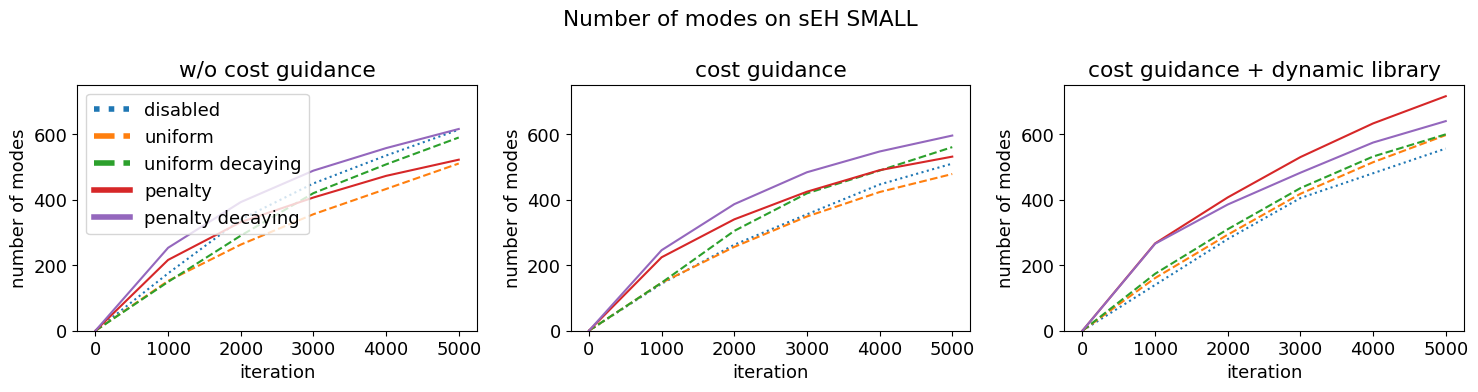

In [5]:
import numpy as np
from typing import Literal
import matplotlib.pyplot as plt

modes_every_n_iteration = 1000
n_forward_in_batch = 64

name_map = {
    'rgfn_cost_biasing_no_exploration': 'disabled',
    'rgfn_cost_biasing': 'uniform',
    'rgfn_cost_biasing_uniform_1000': 'uniform decaying',
    'rgfn_expl_bias_no_linear': 'penalty',
    'rgfn_expl_bias': 'penalty decaying',
    'rgfn_is_decomposable_no_exploration': 'disabled',
    'rgfn_is_decomposable': 'uniform',
    'rgfn_is_decomposable_uniform_1000': 'uniform decaying',
    'rgfn_expl_no_linear': 'penalty',
    'rgfn_expl': 'penalty decaying',
    'dyn_lib_reward_exploitation_pen_1000': 'penalty decaying',
    'dyn_lib_reward_exploitation_pen_none': 'penalty',
    'dyn_lib_reward_no_exploration': 'disabled',
    'dyn_lib_reward_uniform_policy': 'uniform',
    'rgfn_is_decomposable_rnd': 'RND',
    'rgfn_cost_biasing_rnd': 'RND',
    'dyn_lib_reward_uniform_1000': 'uniform decaying'
}

template_map = {
    'rgfn_new_filtered': 'SMALL',
    'synflow_64k': 'MEDIUM',
    'synflow_128k': 'LARGE',
}


def plot_metric(results: TrainingResultsList, metric: str, max_or_std: Literal['max', 'std'] = 'std'):
    results = results.results
    max_len_results_idx = np.argmax([len(result.__getattribute__(metric)) for result in results])
    if 'modes' in metric:
        x = [i * modes_every_n_iteration for i in range(0, len(results[max_len_results_idx].num_modes) + 1)]
        y = [[0] + list(result.num_modes) for result in results]
    else:
        x = range(len(results[max_len_results_idx].num_scaffolds[::n_forward_in_batch]))
        y = [result.__getattribute__(metric)[::n_forward_in_batch] for result in results]

    if metric == 'cheapest_scaffolds_path_costs':
        x = x[1000:]
        y = [y_i[1000:] for y_i in y]

    max_len = max(len(y_i) for y_i in y)
    y = [np.pad(y_i, (0, max_len - len(y_i)), mode='edge') for y_i in y]
    y_mean = np.mean(y, axis=0)
    name = name_map.get(results[0].model_name, results[0].model_name)

    if 'disabled' in name:
        style = ':'
    elif 'uniform' in name:
        style = '--'
    elif 'penalty' in name:
        style = '-'
    elif 'RND' in name:
        style = '-.'
    # style = '-' if 'disabled' in name else '--'
    plt.plot(x, y_mean, label=name, linestyle=style)

    if max_or_std == 'std':
        y_std = np.std(y, axis=0)
        _floor = y_mean - y_std
        _floor[_floor < 0] = 0
        plt.fill_between(x, _floor, y_mean + y_std, alpha=0.3)
    elif max_or_std == 'max':
        y_min = np.min(y, axis=0)
        y_max = np.max(y, axis=0)
        plt.fill_between(x, y_min, y_max, alpha=0.3)

import matplotlib
matplotlib.rcParams.update({'font.size': 13})
plt.figure(figsize=(5 * len(results_dict), 4))
plt.suptitle(f'Number of modes on sEH {template_map[template_name]}')
for i, (model_type, model_results_dict) in enumerate(results_dict.items(), 1):
    plt.subplot(1, len(results_dict), i)
    plt.ylim(0, 750)
    plt.xlabel('iteration')
    plt.ylabel('number of modes')
    plt.title(model_type)
    for model_name, results_list in model_results_dict.items():
        plot_metric(results_list, 'num_modes', 'no')
    if i == 1:
        leg = plt.legend()
        for line in leg.get_lines():
            line.set_linewidth(4.0)
plt.tight_layout()
plt.savefig(f'outputs/exploration_learning_curves_{template_map[template_name]}.pdf')